In [1]:
import scienceplots
import matplotlib.pyplot as plt
from matplotlib import patches

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams['legend.framealpha'] = 1
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

In [2]:
# Setting data path
from socket import gethostname

print(f"host name: {gethostname()}")

# LOCAL
if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    download_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"

# SIH CLUSTER
elif gethostname().startswith("max-"):
    download_dir = "/home/dgxuser/max/data/JWST/"

# OZSTAR
else:
    download_dir = "/fred/oz440/max/data/JWST/"

host name: max-cpu-0-5


In [3]:
prog = "GTO1200"

uncal_dir = f"{download_dir}/{prog}/uncal"
calslope_dir = f"{download_dir}/{prog}/calslope"


In [31]:
from astropy.io import fits
import os

for file in os.listdir(calslope_dir):
    f = fits.open(os.path.join(calslope_dir, file))
    if f[0].header["TARGPROP"] != "HD-218396":
        continue
        
    print(f[0].header["TARGPROP"])
    print(f[0].header["DATE-OBS"])
    print(f["PRIMARY"].header["ROLL_REF"])
    print()

HD-218396
2023-08-03
223.04814900781219



## HR 8799b
RA Offset = 1635.479 +/- 1.234 mas\
Dec Offset = 532.378 +/- 0.589 mas\
Separation = 1719.929 +/- 1.310 mas\
PA = 71.968 +/- 0.013 deg\
Reference: GRAVITY (unpublished)

## HR 8799c
RA Offset = -288.595 +/- 0.262 mas\
Dec Offset = 909.696 +/- 0.083 mas\
Separation = 954.378 +/- 0.108 mas\
PA = 342.398 +/- 0.015 deg\
Reference: GRAVITY (unpublished)

## HR 8799d
RA Offset = -606.157 +/- 2.468 mas\
Dec Offset = -345.260 +/- 1.085 mas\
Separation = 697.598 +/- 2.666 mas\
PA = 240.339 +/- 0.033 deg\
Reference: GRAVITY (unpublished)

In [5]:
import jax.numpy as np

ras  = np.array([1635.479, -288.595, -606.157, -231.598])
dras = np.array([1.234,    0.262,    2.468,    0.182   ])

decs  = np.array([532.378, 909.696, -345.260, 325.951])
ddecs = np.array([0.589,   0.083,    1.085,   0.243  ])

seps  = np.array([1719.929, 954.378, 697.598, 399.834])
dseps = np.array([1.310,    0.108,   2.666,   0.264  ])

pas  = np.array([71.968, 342.398, 240.339, 324.593])
dpas = np.array([0.013,  0.015,   0.033,   0.022  ])

planets = ['b', 'c', 'd', 'e']

ERROR:2026-06-03 07:11:30,836:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


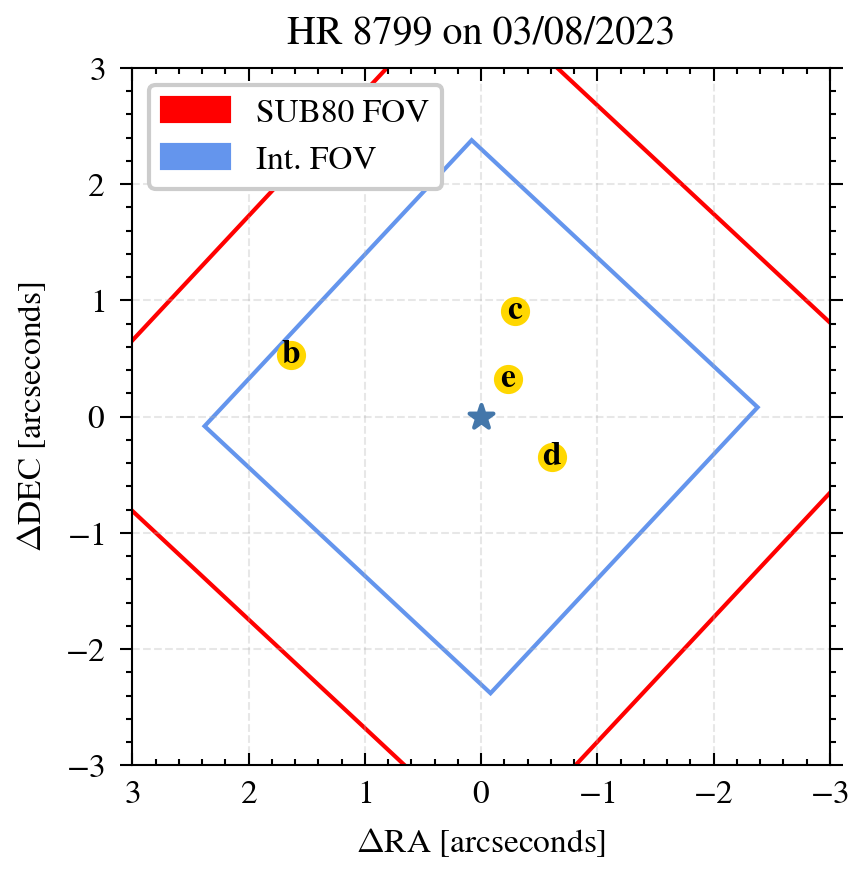

In [34]:
from matplotlib.transforms import Affine2D

lim = 3
tick_gap = 1
fov = 80 * 0.066  # arcseconds
int_fov = 51/80*fov
roll_angle = 223.04814900781219

fig, ax = plt.subplots(figsize=(3, 4))
ax.grid(alpha=0.3, zorder=-10, linestyle="dashed")
ax.scatter(ras/1000, decs/1000, zorder=10, color="gold")
for ra, dec, label in zip(ras/1000, decs/1000, planets):
    ax.text(ra, dec, label, zorder=10, ha='center', va='center', fontweight='bold')
ax.scatter([0], [0], marker="*", zorder=10)
ax.axis("square")
ax.set(
    title="HR 8799 on 03/08/2023",
    xlim=(-lim, lim),
    ylim=(-lim, lim),
    xticks=np.arange(-lim, lim + tick_gap, tick_gap),
    yticks=np.arange(-lim, lim + tick_gap, tick_gap),
    xlabel=r"$\Delta$RA [arcseconds]", 
    ylabel=r"$\Delta$DEC [arcseconds]", 
)
ax.invert_xaxis()
red_patch = patches.Patch(color='red', label='SUB80 FOV')
blue_patch = patches.Patch(color='cornflowerblue', label='Int. FOV')

for fov_size, color, label in [(fov, 'red', 'SUB80 FOV'), (int_fov, 'cornflowerblue', 'Int. FOV')]:
    transform = Affine2D().rotate_deg(roll_angle) + ax.transData
    rect = patches.Rectangle(
        (-fov_size/2, -fov_size/2), fov_size, fov_size,
        linewidth=1, edgecolor=color, facecolor='none',
        transform=transform
    )
    ax.add_patch(rect)
leg = ax.legend(handles=[red_patch, blue_patch], frameon=True)
plt.show()